In [1]:
pip install yfinance pandas matplotlib

Defaulting to user installation because normal site-packages is not writeable
INFO: pip is looking at multiple versions of yfinance to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of yfinance to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
import yfinance as yf
import pandas as pd

In [3]:
ticker = "AAPL"

df = yf.download(
    ticker,
    start="2018-01-01",
    end="2025-01-01"
)

df.head()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,40.267082,40.276435,39.565809,39.776193,102223600
2018-01-03,40.260059,40.802379,40.196947,40.330187,118071600
2018-01-04,40.447071,40.549925,40.225002,40.332529,89738400
2018-01-05,40.907578,40.994067,40.451751,40.542916,94640000
2018-01-08,40.755627,41.050160,40.657445,40.755627,82271200


In [5]:
df.to_csv("AAPL.csv")

In [10]:
df.shape

(1761, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1761 entries, 2018-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1761 non-null   float64
 1   (High, AAPL)    1761 non-null   float64
 2   (Low, AAPL)     1761 non-null   float64
 3   (Open, AAPL)    1761 non-null   float64
 4   (Volume, AAPL)  1761 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 82.5 KB


In [7]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1761.000000,1761.000000,1761.000000,1761.000000,1.761000e+03
mean,121.624395,122.830688,120.281371,121.502884,1.001417e+08
std,59.008726,59.477552,58.447816,58.937160,5.521309e+07
min,33.736996,34.574548,33.691914,34.161702,2.323470e+07
25%,53.993908,54.694892,53.608487,54.178659,6.309290e+07
50%,131.183533,132.668335,129.821765,131.645690,8.671200e+07
75%,168.339325,169.893791,166.905829,168.152483,1.214346e+08
max,257.375580,258.448740,255.994420,256.550862,4.265100e+08


In [8]:
df.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

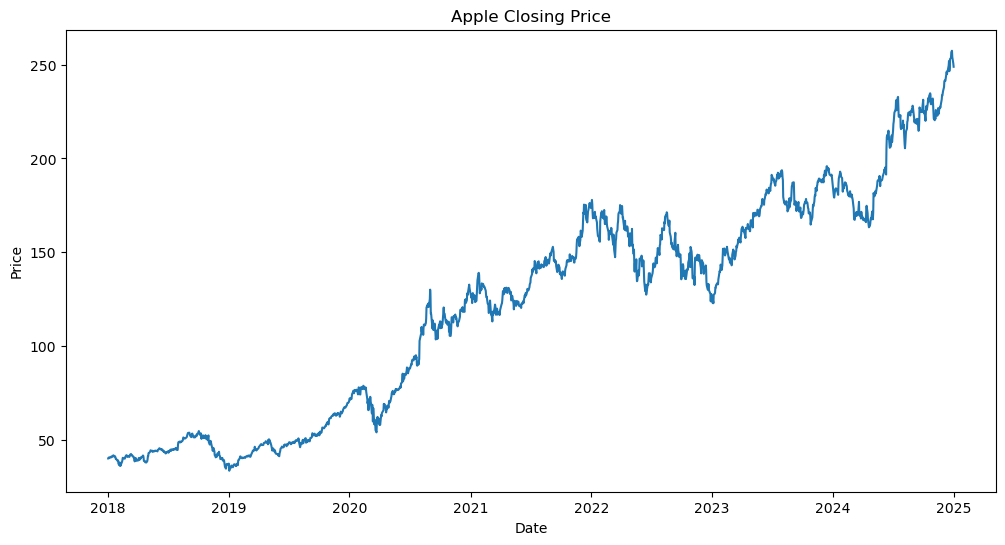

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df["Close"])

plt.title("Apple Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

In [12]:
df["Return"] = df["Close"].pct_change()

In [13]:
df.head()

Price,Close,High,Low,Open,Volume,Return
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2018-01-02,40.267082,40.276435,39.565809,39.776193,102223600,NaN
2018-01-03,40.260059,40.802379,40.196947,40.330187,118071600,-0.000174
2018-01-04,40.447071,40.549925,40.225002,40.332529,89738400,0.004645
2018-01-05,40.907578,40.994067,40.451751,40.542916,94640000,0.011385
2018-01-08,40.755627,41.050160,40.657445,40.755627,82271200,-0.003714


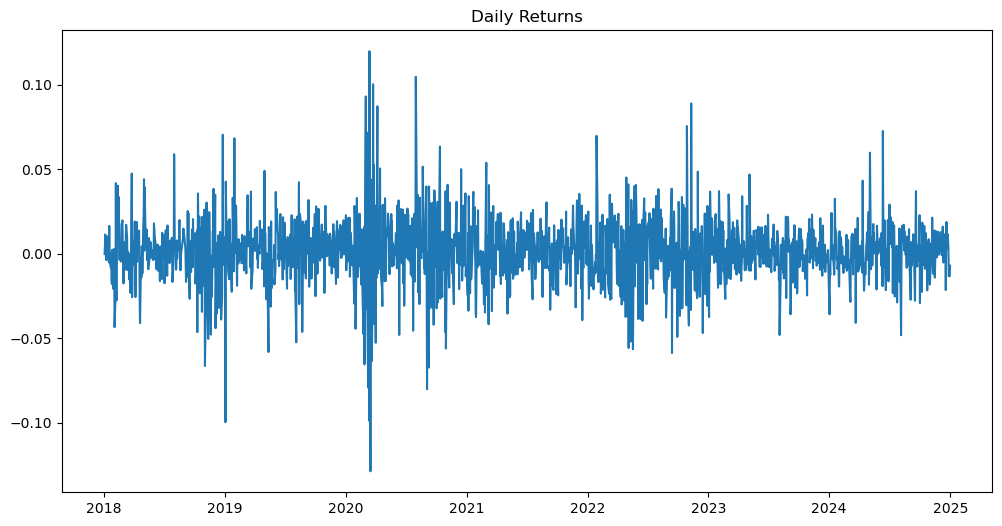

In [14]:
plt.figure(figsize=(12,6))

plt.plot(df["Return"])

plt.title("Daily Returns")
plt.show()

In [15]:
df["MA10"] = df["Close"].rolling(10).mean()

df["MA50"] = df["Close"].rolling(50).mean()

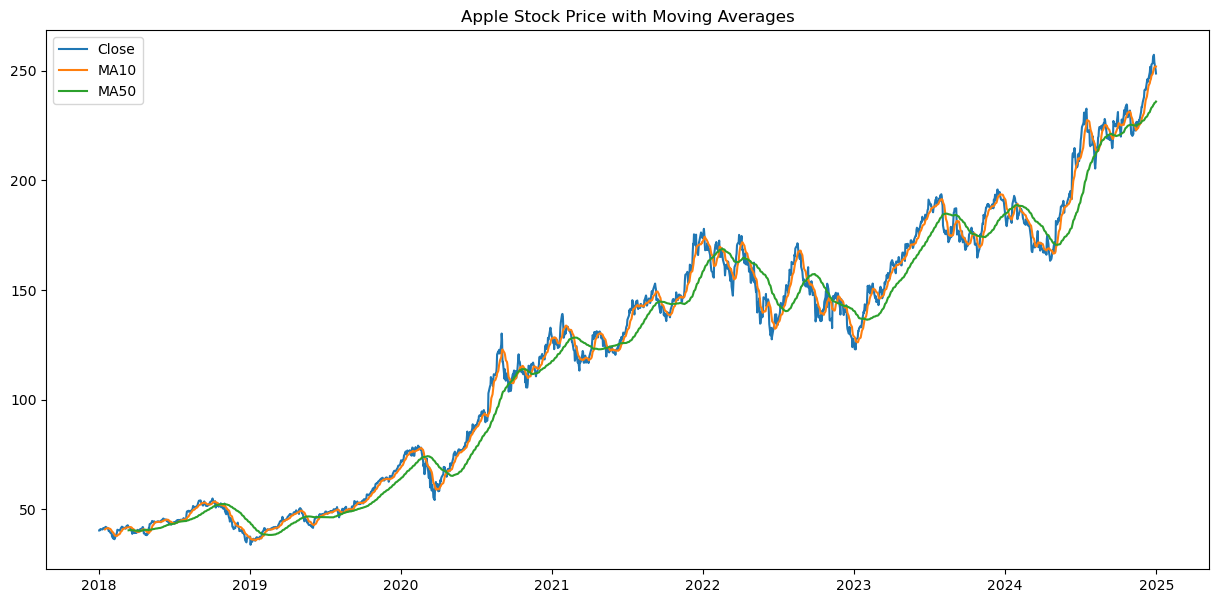

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,7))

plt.plot(df["Close"], label="Close")
plt.plot(df["MA10"], label="MA10")
plt.plot(df["MA50"], label="MA50")

plt.title("Apple Stock Price with Moving Averages")
plt.legend()
plt.show()

In [17]:
df["Volatility"] = df["Return"].rolling(20).std()

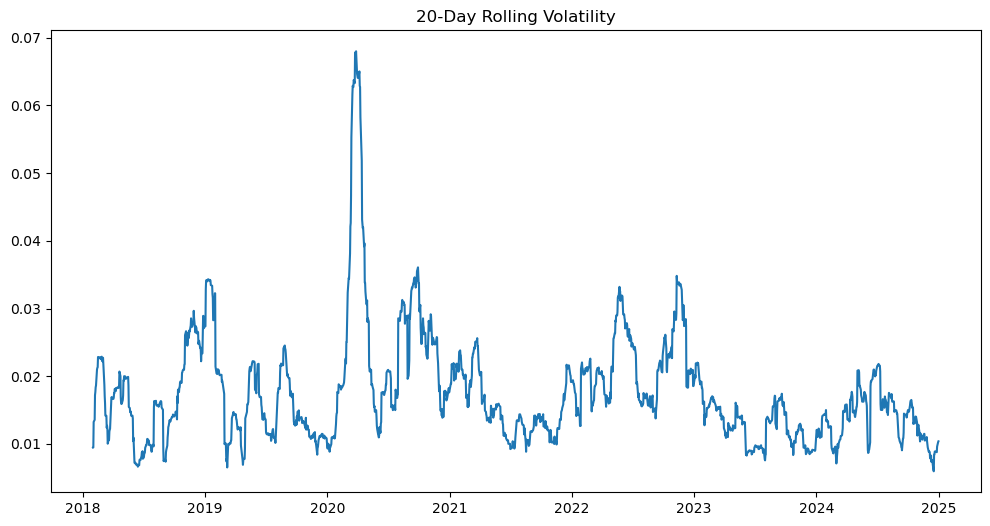

In [18]:
plt.figure(figsize=(12,6))

plt.plot(df["Volatility"])

plt.title("20-Day Rolling Volatility")
plt.show()

In [19]:
pip install ta

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29497 sha256=b17479ee8345b24ee2f641fb559d535cedc6335988563523cdb4cefe889c7ff1
  Stored in directory: c:\users\navne\appdata\local\pip\cache\wheels\e3\3a\ee\4955a26c90a4b7deb6d725dc8ec7b8604a7aef44e43a2e8af7
Successfully built ta
Note: you may need to restart the kernel to use updated packages.


In [23]:
print(df.columns)

MultiIndex([(     'Close', 'AAPL'),
            (      'High', 'AAPL'),
            (       'Low', 'AAPL'),
            (      'Open', 'AAPL'),
            (    'Volume', 'AAPL'),
            (    'Return',     ''),
            (      'MA10',     ''),
            (      'MA50',     ''),
            ('Volatility',     '')],
           names=['Price', 'Ticker'])


In [25]:
print(type(df["Close"]))

<class 'pandas.core.frame.DataFrame'>


In [26]:
df["RSI"] = RSIIndicator(
    close=df["Close"].squeeze(),
    window=14
).rsi()

In [27]:
df[["Close","RSI"]].tail()

Price,Close,RSI
Ticker,AAPL,
Date,,
2024-12-24,256.560822,75.750238
2024-12-26,257.375580,76.452829
2024-12-27,253.967392,67.626297
2024-12-30,250.598892,60.225558
2024-12-31,248.830200,56.715901


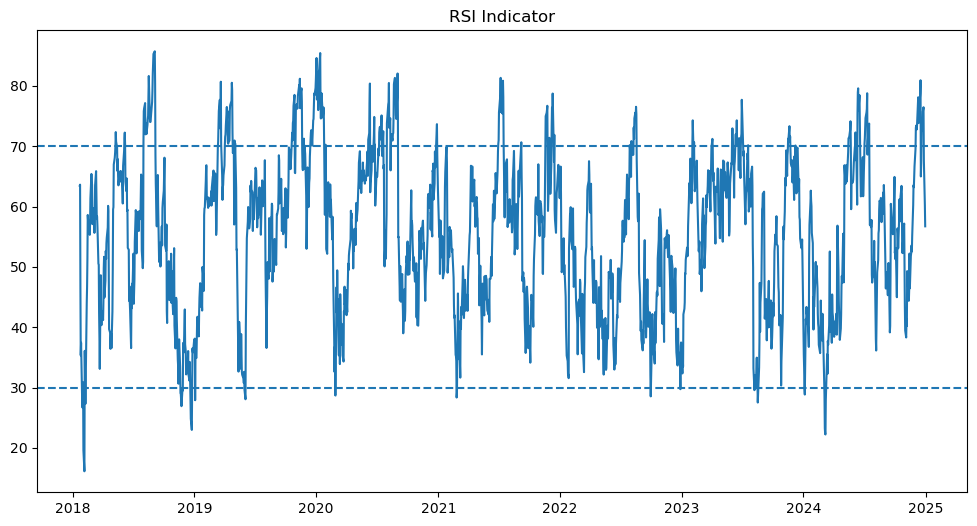

In [28]:
plt.figure(figsize=(12,6))

plt.plot(df["RSI"])

plt.axhline(70, linestyle="--")
plt.axhline(30, linestyle="--")

plt.title("RSI Indicator")
plt.show()

In [29]:
df["Target"] = (
    df["Close"].shift(-1) > df["Close"]
).astype(int)

In [30]:
df[["Close","Target"]].tail()

Price,Close,Target
Ticker,AAPL,
Date,,
2024-12-24,256.560822,1
2024-12-26,257.375580,0
2024-12-27,253.967392,0
2024-12-30,250.598892,0
2024-12-31,248.830200,0


In [31]:
df.columns

MultiIndex([(     'Close', 'AAPL'),
            (      'High', 'AAPL'),
            (       'Low', 'AAPL'),
            (      'Open', 'AAPL'),
            (    'Volume', 'AAPL'),
            (    'Return',     ''),
            (      'MA10',     ''),
            (      'MA50',     ''),
            ('Volatility',     ''),
            (       'RSI',     ''),
            (    'Target',     '')],
           names=['Price', 'Ticker'])

In [32]:
df.isnull().sum()

Price       Ticker
Close       AAPL       0
High        AAPL       0
Low         AAPL       0
Open        AAPL       0
Volume      AAPL       0
Return                 1
MA10                   9
MA50                  49
Volatility            20
RSI                   13
Target                 0
dtype: int64

In [33]:
df = df.dropna()

In [34]:
df.isnull().sum()

Price       Ticker
Close       AAPL      0
High        AAPL      0
Low         AAPL      0
Open        AAPL      0
Volume      AAPL      0
Return                0
MA10                  0
MA50                  0
Volatility            0
RSI                   0
Target                0
dtype: int64

In [35]:
features = [
    "MA10",
    "MA50",
    "RSI",
    "Volume",
    "Volatility"
]

X = df[features]

In [36]:
y = df["Target"]

In [37]:
print(X.shape)
print(y.shape)

(1712, 5)
(1712,)


In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:
predictions = model.predict(X_test)

In [41]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.521865889212828


In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    predictions
)

print(cm)

[[ 75  92]
 [ 72 104]]


In [43]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.51      0.45      0.48       167
           1       0.53      0.59      0.56       176

    accuracy                           0.52       343
   macro avg       0.52      0.52      0.52       343
weighted avg       0.52      0.52      0.52       343



In [44]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
2,"(RSI, )",0.212708
3,"(Volume, AAPL)",0.199951
4,"(Volatility, )",0.197071
1,"(MA50, )",0.196919
0,"(MA10, )",0.193350


In [45]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [46]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [47]:
xgb_predictions = xgb_model.predict(X_test)

In [48]:
from sklearn.metrics import accuracy_score

xgb_accuracy = accuracy_score(
    y_test,
    xgb_predictions
)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.4897959183673469


In [49]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        xgb_predictions
    )
)

              precision    recall  f1-score   support

           0       0.47      0.32      0.38       167
           1       0.50      0.65      0.57       176

    accuracy                           0.49       343
   macro avg       0.48      0.49      0.47       343
weighted avg       0.48      0.49      0.48       343



In [51]:
print(type(df["Close"]))
print(df["Close"].shape)

<class 'pandas.core.frame.DataFrame'>
(1712, 1)


In [53]:
close_series = df["Close"].squeeze()

In [55]:
df.columns

MultiIndex([(      'Close', 'AAPL'),
            (       'High', 'AAPL'),
            (        'Low', 'AAPL'),
            (       'Open', 'AAPL'),
            (     'Volume', 'AAPL'),
            (     'Return',     ''),
            (       'MA10',     ''),
            (       'MA50',     ''),
            ( 'Volatility',     ''),
            (        'RSI',     ''),
            (     'Target',     ''),
            (       'MACD',     ''),
            ('MACD_Signal',     '')],
           names=['Price', 'Ticker'])

In [56]:
df.columns = df.columns.get_level_values(0)

In [57]:
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Return', 'MA10', 'MA50',
       'Volatility', 'RSI', 'Target', 'MACD', 'MACD_Signal'],
      dtype='object', name='Price')

In [58]:
from ta.trend import MACD

macd = MACD(df["Close"])

df["MACD"] = macd.macd()
df["MACD_Signal"] = macd.macd_signal()

In [59]:
from ta.volatility import BollingerBands

bb = BollingerBands(
    close=df["Close"],
    window=20
)

df["BB_High"] = bb.bollinger_hband()
df["BB_Low"] = bb.bollinger_lband()

In [60]:
df["Momentum"] = (
    df["Close"] -
    df["Close"].shift(5)
)

In [61]:
df.isnull().sum()

Price
Close           0
High            0
Low             0
Open            0
Volume          0
Return          0
MA10            0
MA50            0
Volatility      0
RSI             0
Target          0
MACD           25
MACD_Signal    33
BB_High        19
BB_Low         19
Momentum        5
dtype: int64

In [62]:
df = df.dropna()

In [63]:
features = [
    "MA10",
    "MA50",
    "RSI",
    "Volume",
    "Volatility",
    "MACD",
    "MACD_Signal",
    "BB_High",
    "BB_Low",
    "Momentum"
]

In [64]:
X = df[features]

y = df["Target"]

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [66]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [67]:
predictions = model.predict(X_test)

In [68]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    predictions
)

print(accuracy)

0.5297619047619048


In [69]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

       Feature  Importance
2          RSI    0.116780
3       Volume    0.115269
9     Momentum    0.108825
4   Volatility    0.108039
6  MACD_Signal    0.099476
5         MACD    0.097588
7      BB_High    0.092819
0         MA10    0.089029
1         MA50    0.086706
8       BB_Low    0.085470


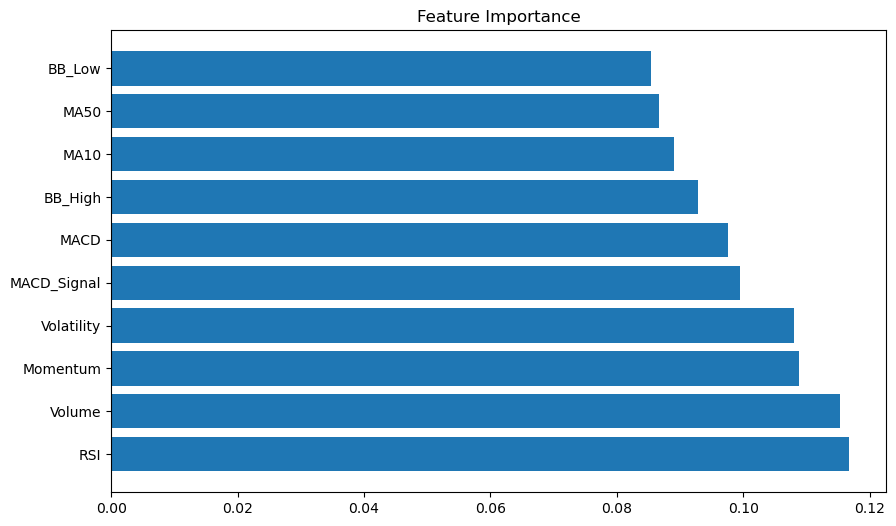

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.show()

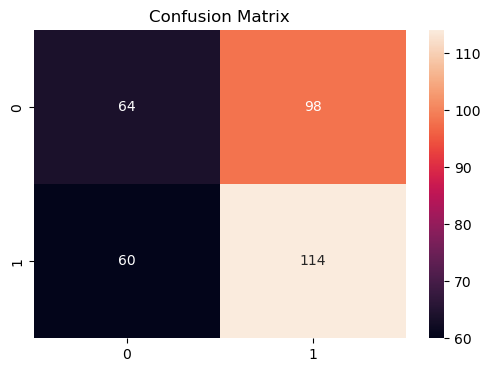

In [71]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.show()

In [73]:
pip install prophet

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.1 MB 1.4 MB/s eta 0:00:08
   --- ------------------------------------ 1.0/12.1 MB 1.4 MB/s eta 0:00:08
   ---- ----------------------------------- 1.3/12.1 MB 1.5 MB/s eta 0:00:08
   ------ --------------------------------- 1.8/12.1 MB 1.6 MB/s eta 0:00:07
   ------ --------------------------------- 2.1/12.1 MB 1.6 MB/s eta 0:00:07
   ------- -------------------------------- 2.4/12.1 MB 1.6 MB/s eta 0:00:07
   --------- ------------------------------ 2.9/12.1 MB 1.7 MB/s eta 0:00:06
   ---------- ----------------------------- 3.1/12.1 MB 1.6 MB/s eta 0:00:06
   ---------- ----------------------------- 3.1/12.1 MB 1.6 MB/s eta 0:00:06
   ---------- -----

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [74]:
from prophet import Prophet

print("Prophet Installed Successfully")

Prophet Installed Successfully


In [75]:
import sys
print(sys.version)

3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]


In [82]:
prophet_df = df.reset_index()

In [83]:
print(prophet_df.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Return', 'MA10',
       'MA50', 'Volatility', 'RSI', 'Target', 'MACD', 'MACD_Signal', 'BB_High',
       'BB_Low', 'Momentum'],
      dtype='object', name='Price')


In [84]:
prophet_df = prophet_df[
    ["Date","Close"]
]

In [86]:
prophet_df.columns = [
    "ds",
    "y"
]

In [87]:
prophet_df.head()

,ds,y
0,2018-05-01,39.689568
1,2018-05-02,41.442856
2,2018-05-03,41.517963
3,2018-05-04,43.146854
4,2018-05-07,43.459015


In [88]:
from prophet import Prophet

prophet_model = Prophet()

In [89]:
prophet_model.fit(prophet_df)

12:12:17 - cmdstanpy - INFO - Chain [1] start processing
12:12:17 - cmdstanpy - INFO - Chain [1] done processing


In [90]:
future = prophet_model.make_future_dataframe(
    periods=30
)

In [91]:
forecast = prophet_model.predict(future)

In [92]:
forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail(10)

,ds,yhat,yhat_lower,yhat_upper
1699,2025-01-21,234.735923,225.595842,244.598988
1700,2025-01-22,234.932142,225.633012,244.290695
1701,2025-01-23,235.176414,225.894668,244.547022
1702,2025-01-24,235.541569,227.043273,245.582955
1703,2025-01-25,230.229958,221.876294,239.644034
1704,2025-01-26,230.571780,220.870516,239.648487
1705,2025-01-27,236.716770,227.784592,246.415993
1706,2025-01-28,237.033325,227.051448,246.027124
1707,2025-01-29,237.256201,228.511618,246.855055
1708,2025-01-30,237.493508,228.135583,246.613431


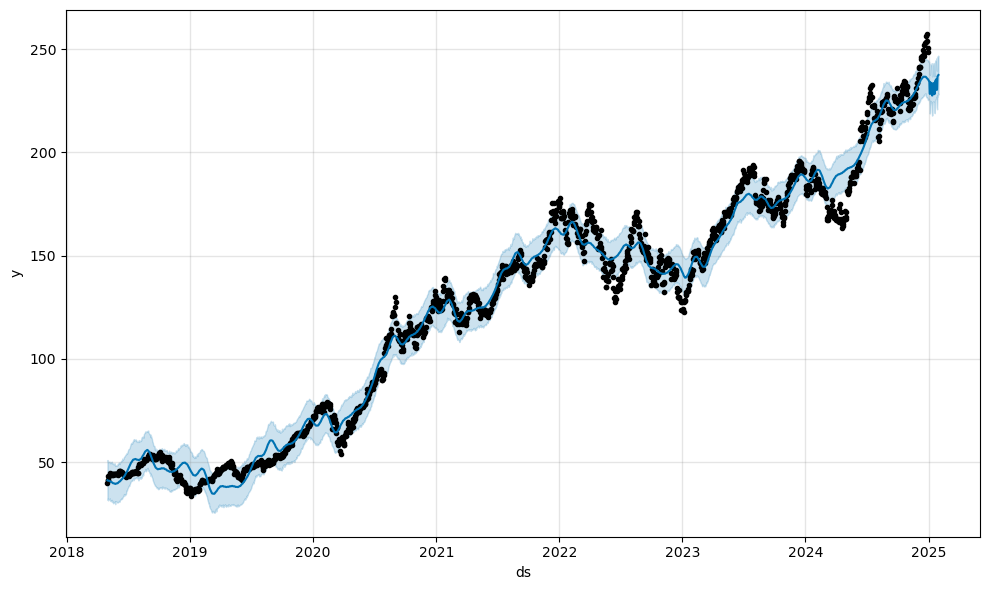

In [93]:
fig = prophet_model.plot(forecast)

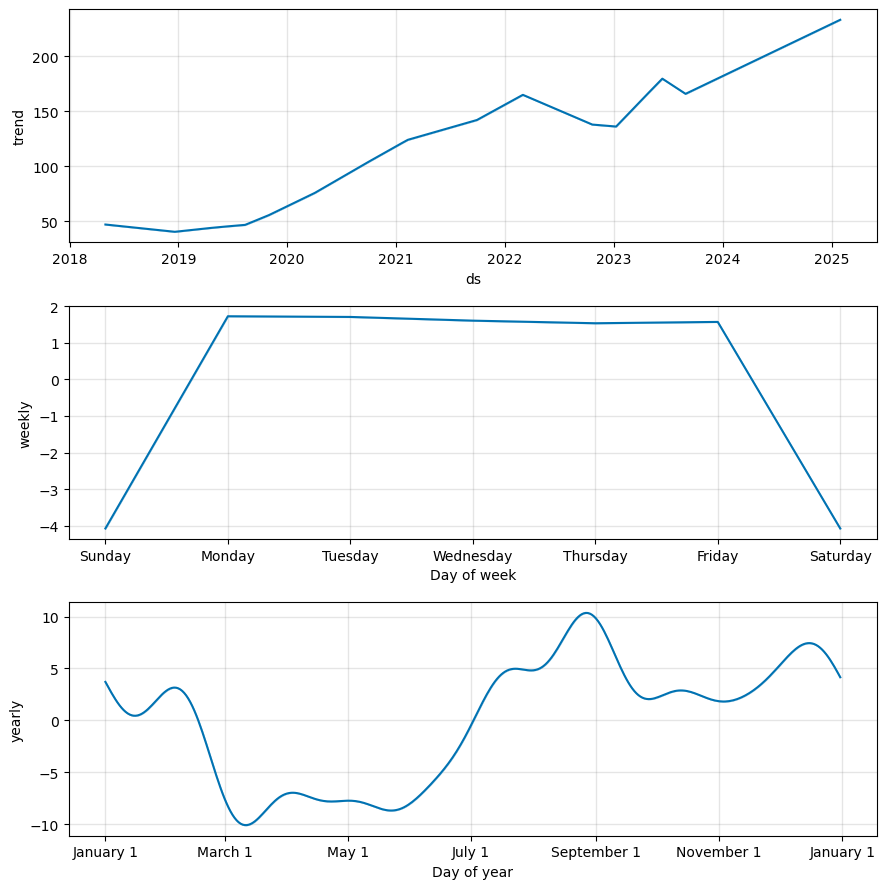

In [94]:
fig2 = prophet_model.plot_components(
    forecast
)